In [1]:
import pandas as pd
from collections import defaultdict

In [2]:
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline  
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore") # Ignore all warnings
# warnings.filterwarnings("ignore", category=RRuntimeWarning) # Show some warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# show all columns
pd.set_option("display.max_columns", None)

by .GlobalEnv when processing object ‘.pbd_env’


In [3]:
%%javascript
// Disable auto-scrolling
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [4]:
%%R

require('tidyverse')
require('DescTools')

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loading required package: tidyverse
Loading required package: DescTools


In [5]:
df2 = pd.read_csv('atp_matches_2023.csv')

# annotate five-set matches
five_set = ['Us Open','Roland Garros', 'Australian Open', 'Wimbledon']
df2['five_set'] = df2.tourney_name.isin(five_set)

df2

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,winner_name,winner_hand,winner_ht,winner_ioc,winner_age,loser_id,loser_seed,loser_entry,loser_name,loser_hand,loser_ht,loser_ioc,loser_age,score,best_of,round,minutes,w_ace,w_df,w_svpt,w_1stIn,w_1stWon,w_2ndWon,w_SvGms,w_bpSaved,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points,five_set
0,2023-9900,United Cup,Hard,18,A,20230102,300,126203,3.0,NaN,Taylor Fritz,R,196.0,USA,25.1,126610,5.0,NaN,Matteo Berrettini,R,196.0,ITA,26.7,7-6(4) 7-6(6),3,F,135.0,15.0,2.0,85.0,52.0,45.0,16.0,12.0,0.0,0.0,7.0,2.0,97.0,62.0,47.0,15.0,12.0,9.0,9.0,9.0,3355.0,16.0,2375.0,False
1,2023-9900,United Cup,Hard,18,A,20230102,299,126207,NaN,NaN,Frances Tiafoe,R,188.0,USA,24.9,207518,NaN,NaN,Lorenzo Musetti,R,185.0,ITA,20.8,6-2 0-0 RET,3,F,34.0,3.0,1.0,27.0,19.0,15.0,3.0,4.0,3.0,3.0,0.0,0.0,21.0,12.0,8.0,3.0,4.0,1.0,3.0,19.0,2000.0,23.0,1865.0,False
2,2023-9900,United Cup,Hard,18,A,20230102,296,126203,3.0,NaN,Taylor Fritz,R,196.0,USA,25.1,128034,2.0,NaN,Hubert Hurkacz,R,196.0,POL,25.8,7-6(5) 7-6(5),3,SF,104.0,11.0,0.0,80.0,50.0,44.0,19.0,12.0,4.0,4.0,17.0,1.0,82.0,62.0,51.0,7.0,12.0,2.0,2.0,9.0,3355.0,10.0,2905.0,False
3,2023-9900,United Cup,Hard,18,A,20230102,295,126207,NaN,NaN,Frances Tiafoe,R,188.0,USA,24.9,200390,NaN,NaN,Kacper Zuk,R,183.0,POL,23.9,6-3 6-3,3,SF,79.0,5.0,4.0,61.0,37.0,31.0,11.0,9.0,5.0,5.0,3.0,3.0,68.0,41.0,26.0,12.0,9.0,6.0,9.0,19.0,2000.0,245.0,220.0,False
4,2023-9900,United Cup,Hard,18,A,20230102,292,126774,1.0,NaN,Stefanos Tsitsipas,R,193.0,GRE,24.3,126610,5.0,NaN,Matteo Berrettini,R,196.0,ITA,26.7,4-6 7-6(2) 6-4,3,SF,155.0,9.0,1.0,98.0,52.0,43.0,28.0,16.0,1.0,2.0,7.0,2.0,89.0,58.0,48.0,18.0,16.0,1.0,2.0,4.0,5550.0,16.0,2375.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2981,2023-M-DC-2023-WG2-PO-RSA-LUX-01,Davis Cup WG2 PO: RSA vs LUX,NaN,4,D,20230204,5,202335,NaN,NaN,Raphael Calzi,R,180.0,LUX,25.5,209280,NaN,NaN,Devin Badenhorst,R,NaN,RSA,18.6,6-4 7-5,3,RR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1717.0,1.0,False
2982,2023-M-DC-2023-WG2-PO-TUN-CYP-01,Davis Cup WG2 PO: TUN vs CYP,NaN,4,D,20230203,1,117365,NaN,NaN,Petros Chrysochos,R,185.0,CYP,26.8,109734,NaN,NaN,Skander Mansouri,R,193.0,TUN,27.5,6-4 7-6(4),3,RR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,990.0,11.0,279.0,190.0,False
2983,2023-M-DC-2023-WG2-PO-TUN-CYP-01,Davis Cup WG2 PO: TUN vs CYP,NaN,4,D,20230203,2,121411,NaN,NaN,Moez Echargui,R,178.0,TUN,30.0,144949,NaN,NaN,Menelaos Efstathiou,R,183.0,CYP,23.9,6-1 3-6 6-2,3,RR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,364.0,131.0,894.0,15.0,False
2984,2023-M-DC-2023-WG2-PO-TUN-CYP-01,Davis Cup WG2 PO: TUN vs CYP,NaN,4,D,20230203,4,144949,NaN,NaN,Menelaos Efstathiou,R,183.0,CYP,23.9,144826,NaN,NaN,Aziz Dougaz,L,188.0,TUN,25.8,3-6 6-1 6-4,3,RR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,894.0,15.0,285.0,184.0,False


In [6]:
# Load match data
df = pd.read_csv('atp_matches_2023.csv')
df = df.sort_values('tourney_date')

five_set = ['Us Open','Roland Garros', 'Australian Open', 'Wimbledon']
df['five_set'] = df.tourney_name.isin(five_set)


# Initialize Elo ratings
elo_ratings = defaultdict(lambda: 1500)

# Store Elo snapshot *before* each match
elo_snapshots = []

K = 30

def win_prob(rating_i, rating_j):
    return 1 / (1 + 10 ** ((rating_j - rating_i) / 400))

for _, match in df.iterrows():
    winner = match['winner_name']
    loser = match['loser_name']

    rating_winner = elo_ratings[winner]
    rating_loser = elo_ratings[loser]

    # Record pre-match Elo ratings
    elo_snapshots.append({
        'date': match['tourney_date'],
        'surface': match['surface'],
        'tournament': match['tourney_name'],
        'winner': winner,
        'loser': loser,
        'five_set': match['five_set'],
        'winner_elo_before': rating_winner,
        'loser_elo_before': rating_loser
    })

    # Calculate expected outcomes
    expected_win = win_prob(rating_winner, rating_loser)
    expected_loss = 1 - expected_win

    # Update ratings
    elo_ratings[winner] += K * (1 - expected_win)
    elo_ratings[loser] += K * (0 - expected_loss)

# Create DataFrame
elo_df = pd.DataFrame(elo_snapshots)
elo_df

,date,surface,tournament,winner,loser,five_set,winner_elo_before,loser_elo_before
0,20230102,Hard,United Cup,Taylor Fritz,Matteo Berrettini,False,1500.000000,1500.000000
1,20230102,Hard,Adelaide 1,Alexei Popyrin,Felix Auger Aliassime,False,1500.000000,1500.000000
2,20230102,Hard,Adelaide 1,Marcos Giron,Richard Gasquet,False,1500.000000,1500.000000
3,20230102,Hard,Adelaide 1,Mackenzie Mcdonald,Daniel Elahi Galan,False,1500.000000,1500.000000
4,20230102,Hard,Adelaide 1,Yoshihito Nishioka,Holger Rune,False,1500.000000,1500.000000
...,...,...,...,...,...,...,...,...
2981,20231127,Hard,NextGen Finals,Hamad Medjedovic,Luca Van Assche,False,1559.394870,1476.388274
2982,20231127,Hard,NextGen Finals,Hamad Medjedovic,Abedallah Shelbayh,False,1570.877850,1447.949709
2983,20231127,Hard,NextGen Finals,Abedallah Shelbayh,Alex Michelsen,False,1438.046036,1489.435844
2984,20231127,Hard,NextGen Finals,Luca Van Assche,Abedallah Shelbayh,False,1464.905294,1455.248672


In [7]:
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Randomly assign winner to be Player A or B
winner_is_A = np.random.randint(0, 2, size=len(elo_df)) == 1

# Create transformed DataFrame
elo_transformed = pd.DataFrame({
    'date': elo_df['date'],
    'tournament': elo_df['tournament'],
    'surface' : elo_df['surface'],
    'five_set': elo_df['five_set'],
    'player_A_name': np.where(winner_is_A, elo_df['winner'], elo_df['loser']),
    'player_B_name': np.where(winner_is_A, elo_df['loser'], elo_df['winner']),
    
    'player_A_elo_before': np.where(winner_is_A, elo_df['winner_elo_before'], elo_df['loser_elo_before']),
    'player_B_elo_before': np.where(winner_is_A, elo_df['loser_elo_before'], elo_df['winner_elo_before']),
    
    'player_A_win': winner_is_A.astype(int)
})
elo_transformed

,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win
0,20230102,United Cup,Hard,False,Matteo Berrettini,Taylor Fritz,1500.000000,1500.000000,0
1,20230102,Adelaide 1,Hard,False,Alexei Popyrin,Felix Auger Aliassime,1500.000000,1500.000000,1
2,20230102,Adelaide 1,Hard,False,Richard Gasquet,Marcos Giron,1500.000000,1500.000000,0
3,20230102,Adelaide 1,Hard,False,Daniel Elahi Galan,Mackenzie Mcdonald,1500.000000,1500.000000,0
4,20230102,Adelaide 1,Hard,False,Holger Rune,Yoshihito Nishioka,1500.000000,1500.000000,0
...,...,...,...,...,...,...,...,...,...
2981,20231127,NextGen Finals,Hard,False,Hamad Medjedovic,Luca Van Assche,1559.394870,1476.388274,1
2982,20231127,NextGen Finals,Hard,False,Abedallah Shelbayh,Hamad Medjedovic,1447.949709,1570.877850,0
2983,20231127,NextGen Finals,Hard,False,Alex Michelsen,Abedallah Shelbayh,1489.435844,1438.046036,0
2984,20231127,NextGen Finals,Hard,False,Luca Van Assche,Abedallah Shelbayh,1464.905294,1455.248672,1


In [8]:
elo_transformed['elo_difference'] = elo_transformed['player_A_elo_before'] - elo_transformed ['player_B_elo_before']
elo_transformed

,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference
0,20230102,United Cup,Hard,False,Matteo Berrettini,Taylor Fritz,1500.000000,1500.000000,0,0.000000
1,20230102,Adelaide 1,Hard,False,Alexei Popyrin,Felix Auger Aliassime,1500.000000,1500.000000,1,0.000000
2,20230102,Adelaide 1,Hard,False,Richard Gasquet,Marcos Giron,1500.000000,1500.000000,0,0.000000
3,20230102,Adelaide 1,Hard,False,Daniel Elahi Galan,Mackenzie Mcdonald,1500.000000,1500.000000,0,0.000000
4,20230102,Adelaide 1,Hard,False,Holger Rune,Yoshihito Nishioka,1500.000000,1500.000000,0,0.000000
...,...,...,...,...,...,...,...,...,...,...
2981,20231127,NextGen Finals,Hard,False,Hamad Medjedovic,Luca Van Assche,1559.394870,1476.388274,1,83.006596
2982,20231127,NextGen Finals,Hard,False,Abedallah Shelbayh,Hamad Medjedovic,1447.949709,1570.877850,0,-122.928140
2983,20231127,NextGen Finals,Hard,False,Alex Michelsen,Abedallah Shelbayh,1489.435844,1438.046036,0,51.389809
2984,20231127,NextGen Finals,Hard,False,Luca Van Assche,Abedallah Shelbayh,1464.905294,1455.248672,1,9.656621


## Ground truth


Attaching package: ‘flexplot’

The following object is masked from ‘package:ggplot2’:

    flip_data



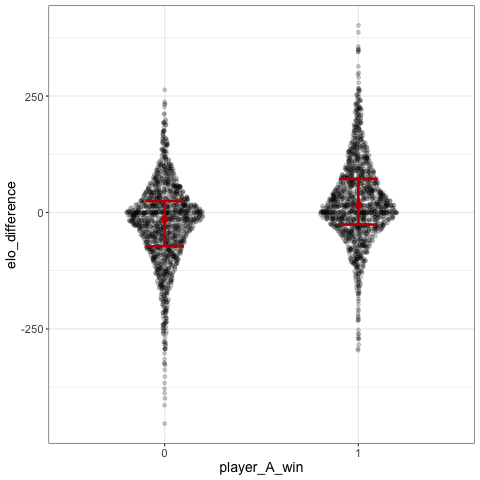

In [9]:
%%R -i elo_transformed

library(flexplot)
flexplot(elo_difference ~ player_A_win, data=elo_transformed)

In [25]:
%%R 

logistic <- glm(player_A_win ~ elo_difference + elo_difference:five_set, data=elo_transformed, family=binomial)
print(summary(logistic))
print(PseudoR2(logistic, which="McFadden"))



Call:
glm(formula = player_A_win ~ elo_difference + elo_difference:five_set, 
    family = binomial, data = elo_transformed)

Coefficients:
                              Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 -0.0222114  0.0380964  -0.583  0.55987    
elo_difference               0.0057762  0.0005125  11.270  < 2e-16 ***
elo_difference:five_setTRUE  0.0041109  0.0012930   3.179  0.00148 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 4139.0  on 2985  degrees of freedom
Residual deviance: 3894.6  on 2983  degrees of freedom
AIC: 3900.6

Number of Fisher Scoring iterations: 4

  McFadden 
0.05904692 


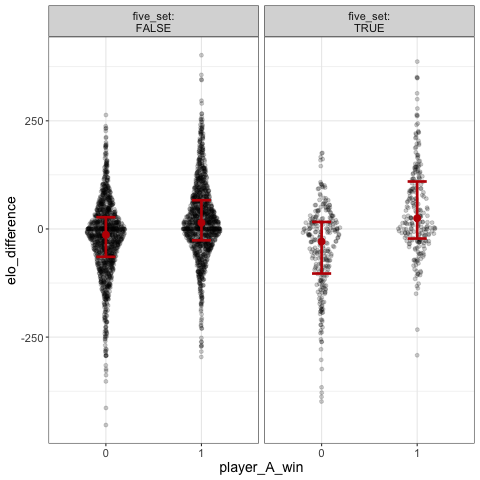

In [29]:
%%R 

flexplot(elo_difference ~ player_A_win | five_set, data=elo_transformed)

In [11]:
%%R 

df <- elo_transformed %>% mutate(
    predict_proba_R = predict(logistic, type="response"),
    predict_R = ifelse(predict_proba_R > .5, 1,0)
) %>% arrange(elo_difference)

df %>% head()

         date         tournament surface five_set           player_A_name
2085 20230807     Canada Masters    Hard    FALSE             Ben Shelton
2147 20230814 Cincinnati Masters    Hard    FALSE             Max Purcell
2346 20230828            Us Open    Hard     TRUE Bernabe Zapata Miralles
2359 20230828            Us Open    Hard     TRUE            Lloyd Harris
2365 20230828            Us Open    Hard     TRUE        Alexandre Muller
2325 20230828            Us Open    Hard     TRUE             Ben Shelton
      player_B_name player_A_elo_before player_B_elo_before player_A_win
2085 Carlos Alcaraz            1410.849            1864.117            0
2147 Carlos Alcaraz            1432.600            1846.424            0
2346 Novak Djokovic            1458.761            1857.669            0
2359 Carlos Alcaraz            1464.366            1852.335            0
2365 Novak Djokovic            1481.946            1860.412            0
2325 Novak Djokovic            1476.306     

## Analyzing residuals

In [12]:
%%R

library(dplyr)

df_filtered <- df %>%
  filter(player_A_win != predict_R) %>%
  arrange(desc(predict_proba_R))

head(df_filtered)

         date                   tournament surface five_set      player_A_name
2860 20231030                Paris Masters    Hard    FALSE     Carlos Alcaraz
2644 20231002             Shanghai Masters    Hard    FALSE      Jannik Sinner
2411 20230915 Davis Cup WG1 R1: DEN vs BRA    Hard    FALSE        Holger Rune
1557 20230612                    Stuttgart   Grass    FALSE Stefanos Tsitsipas
2094 20230807               Canada Masters    Hard    FALSE Stefanos Tsitsipas
2005 20230731                   Washington    Hard    FALSE    Grigor Dimitrov
       player_B_name player_A_elo_before player_B_elo_before player_A_win
2860 Roman Safiullin            1837.876            1574.445            0
2644     Ben Shelton            1784.218            1546.589            0
2411 Thiago Monteiro            1664.950            1431.678            0
1557 Richard Gasquet            1696.759            1464.841            0
2094    Gael Monfils            1699.698            1473.198            0
200

In [13]:
%%R

library(dplyr)

df_filtered <- df %>%
  filter(player_A_win != predict_R) %>%
  arrange((predict_proba_R))

head(df_filtered)

         date      tournament surface five_set         player_A_name
1941 20230724         Hamburg    Clay    FALSE       Daniel Altmaier
1409 20230529   Roland Garros    Clay     TRUE   Thiago Seyboth Wild
1251 20230508    Rome Masters    Clay    FALSE       Fabian Marozsan
2105 20230807  Canada Masters    Hard    FALSE            Tommy Paul
1621 20230619           Halle   Grass    FALSE Roberto Bautista Agut
1528 20230612 s Hertogenbosch   Grass    FALSE      Adrian Mannarino
       player_B_name player_A_elo_before player_B_elo_before player_A_win
1941   Andrey Rublev            1446.236            1742.111            1
1409 Daniil Medvedev            1500.000            1791.986            1
1251  Carlos Alcaraz            1500.038            1783.473            1
2105  Carlos Alcaraz            1599.816            1871.224            1
1621 Daniil Medvedev            1470.555            1741.957            1
1528 Daniil Medvedev            1497.795            1766.695            1

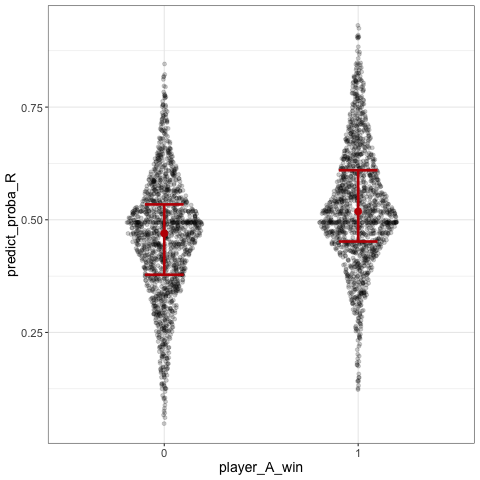

In [14]:
%%R 

flexplot(predict_proba_R ~ player_A_win, data=df, method='lm')

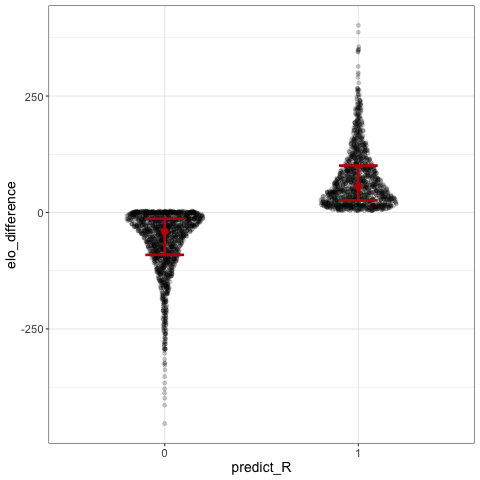

In [15]:
%%R 

flexplot(elo_difference ~ predict_R, data=df)

In [16]:
%%R 

# Create confusion matrix
conf_mat <- table(df$predict_R, df$player_A_win)
print(conf_mat) 

# Extract TP, FP, FN
TP <- conf_mat[2,2]
FP <- conf_mat[2,1]
FN <- conf_mat[1,2]
# Calculate Precision and Recall
precision <- TP / (TP + FP)
recall <- TP / (TP + FN)
# Print
cat("Precision:", precision, "\n")
cat("Recall:", recall, "\n")

   
      0   1
  0 980 653
  1 532 821
Precision: 0.6067997 
Recall: 0.5569878 
